<a href="https://colab.research.google.com/github/Dakshaayini/northstar-analytics/blob/main/notebooks/03_Python_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load all datasets
customers  = pd.read_csv('customers.csv')
orders     = pd.read_csv('orders.csv',     parse_dates=['order_created_at'])
deliveries = pd.read_csv('deliveries.csv', parse_dates=['dispatch_time','delivery_completed_at'])
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv')
incidents  = pd.read_csv('incidents.csv',  parse_dates=['reported_at'])
complaints = pd.read_csv('complaints.csv', parse_dates=['created_at'])
app_events = pd.read_csv('app_events.csv', parse_dates=['event_timestamp'])

In [4]:
# Cell 3: Quick audit
for name, df in [('customers',customers),('orders',orders),
                  ('deliveries',deliveries),('incidents',incidents)]:
    print(f'{name}: {df.shape[0]} rows | {df.isnull().sum().sum()} missing values')

customers: 650 rows | 33 missing values
orders: 1250 rows | 25 missing values
deliveries: 950 rows | 33 missing values
incidents: 280 rows | 17 missing values


In [5]:
# Cell 4: Standardise zone name capitalisation
orders['pickup_zone']     = orders['pickup_zone'].str.strip().str.title()
orders['dropoff_zone']    = orders['dropoff_zone'].str.strip().str.title()
customers['home_zone']    = customers['home_zone'].str.strip().str.title()
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.strip().str.title()

In [6]:
# Cell 5: Fill missing values with column median
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)
vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].median(), inplace=True)
customers['loyalty_score'].fillna(
    customers['loyalty_score'].median(), inplace=True)

In [7]:
# Cell 6: Engineer new feature — delivery delay in minutes
deliveries['delivery_delay_mins'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 60

In [8]:
# Verify: check zone names are now clean
print(orders['pickup_zone'].value_counts().head(10))
print('Remaining nulls:')
print(deliveries.isnull().sum()[deliveries.isnull().sum()>0])

pickup_zone
East         207
South        181
North        174
Central      158
West         155
Riverside    151
Airport      144
Ctr           80
Name: count, dtype: int64
Remaining nulls:
delivery_completed_at    19
delivery_delay_mins      19
dtype: int64


In [9]:
# Cell 7: Descriptive statistics
print('=== Delivery Delay (minutes) ===')
print(f'Mean:        {np.mean(deliveries["delivery_delay_mins"].dropna()):.1f}')
print(f'Median:      {np.median(deliveries["delivery_delay_mins"].dropna()):.1f}')
print(f'Std Dev:     {np.std(deliveries["delivery_delay_mins"].dropna()):.1f}')
print(f'95th pctile: {np.percentile(deliveries["delivery_delay_mins"].dropna(), 95):.1f}')

print('\n=== Customer Rating ===')
print(deliveries.groupby('delivery_status')['customer_rating_post_delivery'].mean().round(2))

=== Delivery Delay (minutes) ===
Mean:        572.7
Median:      424.5
Std Dev:     518.6
95th pctile: 1480.1

=== Customer Rating ===
delivery_status
Delayed    3.14
Failed     3.06
OnTime     4.28
Name: customer_rating_post_delivery, dtype: float64


In [10]:
# Cell 8: Complaint pivot table — zone vs complaint type
comp_merged = complaints.merge(
    orders[['order_id','pickup_zone']], on='order_id', how='left')
comp_merged['pickup_zone'] = comp_merged['pickup_zone'].str.strip().str.title()

pivot = comp_merged.pivot_table(
    values='complaint_id', index='pickup_zone',
    columns='complaint_type', aggfunc='count', fill_value=0)
print(pivot)

complaint_type  AppIssue  Billing  Damage  Delay  DriverBehaviour  \
pickup_zone                                                         
Airport                3        3       0     10                5   
Central               11        0       0     15                7   
Ctr                    2        1       2      6                4   
East                   8        4       5     14                6   
North                  6        4       2     17                9   
Riverside             12        0       0     15                6   
South                  8        2       2     14                6   
West                   3        2       4     10                8   

complaint_type  MissedPickup  SupportExperience  
pickup_zone                                      
Airport                    7                  4  
Central                    9                  0  
Ctr                        3                  0  
East                      10                  3  
North    

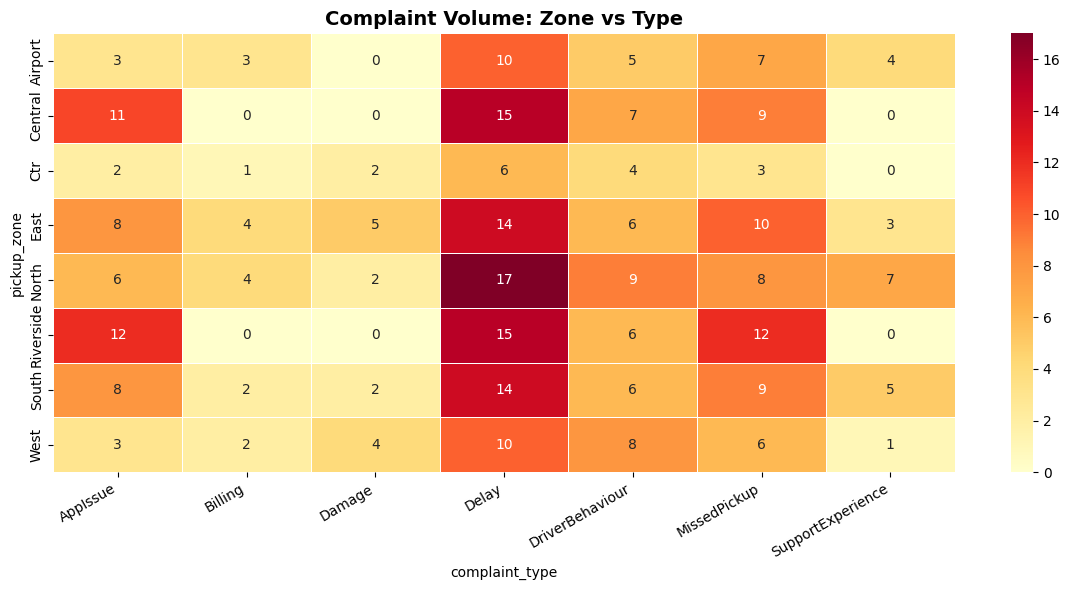

In [11]:
# Cell 9: Heatmap of complaint pivot
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Complaint Volume: Zone vs Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('complaint_heatmap.png', dpi=150)
plt.show()

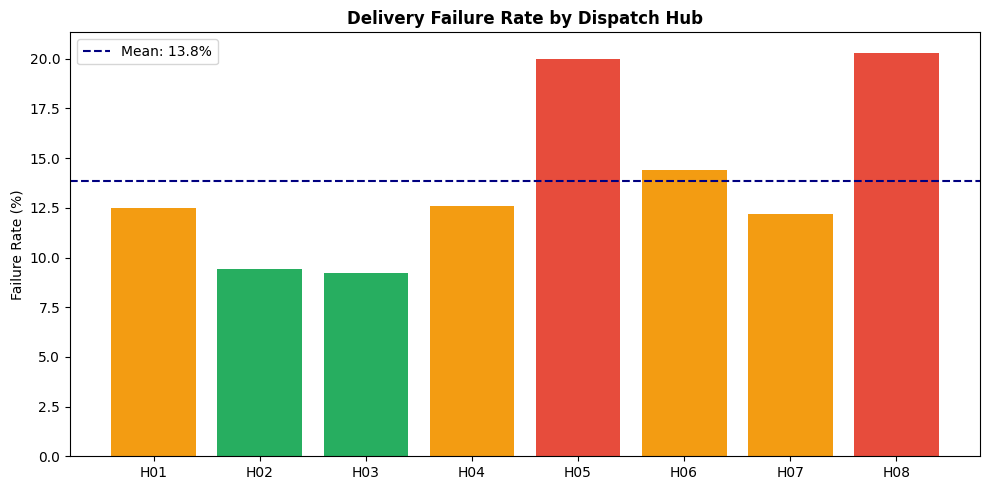

In [12]:
# Cell 10: Bar chart — hub failure rates
hub_stats = deliveries.groupby('hub_id').agg(
    total=('delivery_id','count'),
    failed=('delivery_status', lambda x:(x=='Failed').sum())
).reset_index()
hub_stats['failure_rate'] = hub_stats['failed']/hub_stats['total']*100
mean_rate = hub_stats['failure_rate'].mean()

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#E74C3C' if r>15 else '#F39C12' if r>10 else '#27AE60'
          for r in hub_stats['failure_rate']]
ax.bar(hub_stats['hub_id'], hub_stats['failure_rate'], color=colors)
ax.axhline(mean_rate, color='navy', linestyle='--',
           label=f'Mean: {mean_rate:.1f}%')
ax.set_title('Delivery Failure Rate by Dispatch Hub', fontweight='bold')
ax.set_ylabel('Failure Rate (%)'); ax.legend()
plt.tight_layout(); plt.savefig('hub_failures.png', dpi=150); plt.show()

Mean latency:         465.7 ms
Events above 500ms:   257
Payment retries:      69
Chat escalations:     38


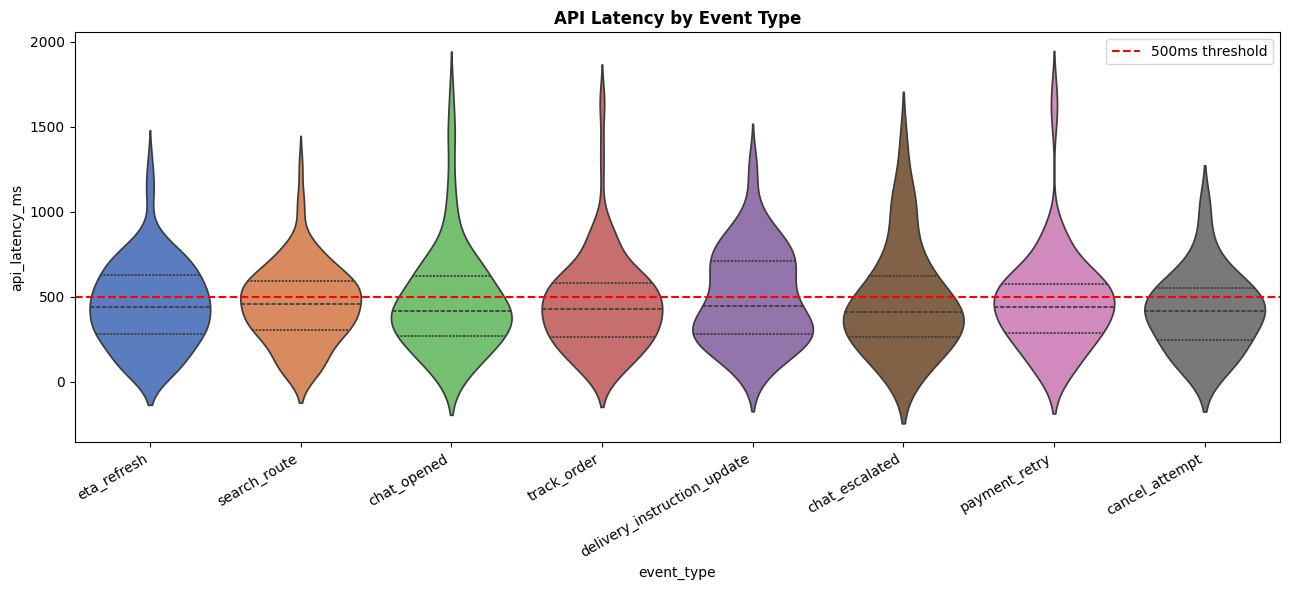

In [13]:
# Cell 11: App API latency statistics
print(f"Mean latency:         {app_events['api_latency_ms'].mean():.1f} ms")
print(f"Events above 500ms:   {(app_events['api_latency_ms']>500).sum()}")
print(f"Payment retries:      {(app_events['event_type']=='payment_retry').sum()}")
print(f"Chat escalations:     {(app_events['event_type']=='chat_escalated').sum()}")

# Violin plot of latency by event type
fig, ax = plt.subplots(figsize=(13,6))
sns.violinplot(data=app_events, x='event_type', y='api_latency_ms',
               palette='muted', inner='quartile', ax=ax)
ax.axhline(500, color='red', linestyle='--', label='500ms threshold')
ax.set_title('API Latency by Event Type', fontweight='bold')
plt.xticks(rotation=30, ha='right'); ax.legend()
plt.tight_layout(); plt.savefig('app_latency.png', dpi=150); plt.show()